# DBSCAN nos angulos diedros

O K-means precisa que a gente diga de antemao quantos estados existem ($K$). O DBSCAN e' um metodo diferente: em vez de $K$, ele recebe uma nocao de densidade (`eps`, `min_samples`) e decide sozinho quantos grupos existem — e, o que e' novo, ele pode dizer que um ponto **nao pertence a nenhum grupo** ("ruido"), em vez de forcar todo ponto para dentro de algum cluster.

Mesma ressalva de sempre: o `DBSCAN` do scikit-learn usa distancia euclidiana comum, que nao entende que os angulos sao periodicos ($-179°$ e $179°$ sao vizinhos, nao opostos). Aqui vamos usar assim mesmo, nos angulos crus, para manter simples — e comentar no final o que isso pode estar afetando.

## Carregando a trajetoria e as features

Mesma receita dos notebooks anteriores: raio de giro, RMSD e os 12 angulos diedros do esqueleto (phi/psi de cada um dos 6 residuos de alanina).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import rms

u = mda.Universe("trajectory.xyz", to_guess=["bonds", "angles", "dihedrals", "masses"], dt=10)
molecule = u.select_atoms('all')

radgyr = np.zeros(len(u.trajectory))
for ts in u.trajectory:
    radgyr[ts.frame] = molecule.radius_of_gyration()

R = rms.RMSD(u, u, select='all', ref_frame=0)
R.run()
rmsd = R.results.rmsd[:, 2]

dihedral_indices = [3, 7, 15, 19, 27, 31, 39, 43, 51, 55, 63, 67]
dihedral_cols = [f"dihedral{i}" for i in dihedral_indices]

lst = []
for ts in u.trajectory:
    row = {"time": ts.time, "radgyr": radgyr[ts.frame], "rmsd": rmsd[ts.frame]}
    for col, idx in zip(dihedral_cols, dihedral_indices):
        row[col] = u.dihedrals[idx].value()
    lst.append(row)

df_features = pd.DataFrame(lst)
dihedral_names = df_features.columns[3:]
features = df_features[dihedral_cols].values
features.shape

(2000, 12)

## Escolhendo `eps` com o grafico k-distancia

E' a forma padrao de escolher o `eps`: para cada ponto, mede-se a distancia ate seu `min_samples`-esimo vizinho mais proximo, ordena-se esses valores, e procura-se o "joelho" da curva — o ponto onde a distancia comeca a crescer rapido. Isso separa a regiao densa (pontos proximos de muitos vizinhos) da regiao esparsa (pontos isolados, que viram ruido).

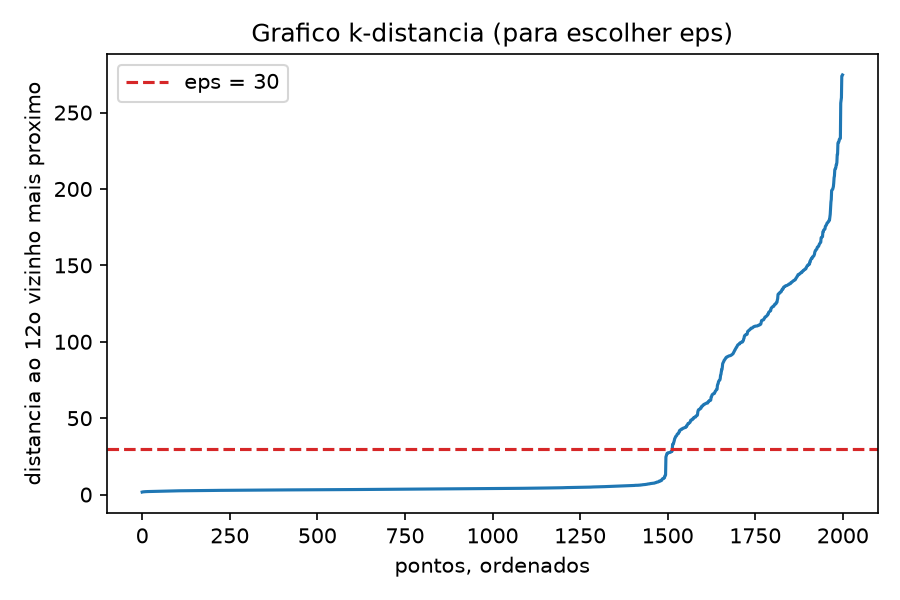

In [ ]:
from sklearn.neighbors import NearestNeighbors

min_samples = 12
nn = NearestNeighbors(n_neighbors=min_samples).fit(features)
dist, _ = nn.kneighbors(features)
kth = np.sort(dist[:, -1])

plt.figure(dpi=100)
plt.plot(kth)
plt.axhline(30, color="C3", ls="--", label="eps = 30")
plt.xlabel("pontos, ordenados")
plt.ylabel(f"distancia ao {min_samples}o vizinho mais proximo")
plt.title("Grafico k-distancia (para escolher eps)")
plt.legend()
plt.show()

O joelho fica bem marcado perto de 30 -- e' o valor de `eps` que usamos abaixo.

## Rodando o DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

eps = 30.0
db = DBSCAN(eps=eps, min_samples=min_samples).fit(features)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"{n_clusters} clusters encontrados")
print(f"{n_noise} pontos classificados como ruido ({100*n_noise/len(labels):.1f}%)")

sizes = np.array([(labels == c).sum() for c in sorted(set(labels) - {-1})])
print(f"tamanho dos clusters: min={sizes.min()}, max={sizes.max()}, mediana={int(np.median(sizes))}")

34 clusters encontrados
486 pontos classificados como ruido (24.3%)
tamanho dos clusters: min=12, max=225, mediana=22


Bem diferente do K-means: sem escolher $K$, o DBSCAN encontra **34** grupos, a maioria pequeno (mediana de 22 pontos), e classifica quase um quarto da trajetoria (24%) como ruido -- nao pertencente a nenhuma regiao densa.

## Onde esta o ruido? (Ramachandran colorido)

Em vez de colorir por cada um dos 34 clusters (ficaria ilegivel), marcamos so' duas categorias: pertence a algum cluster, ou e' ruido.

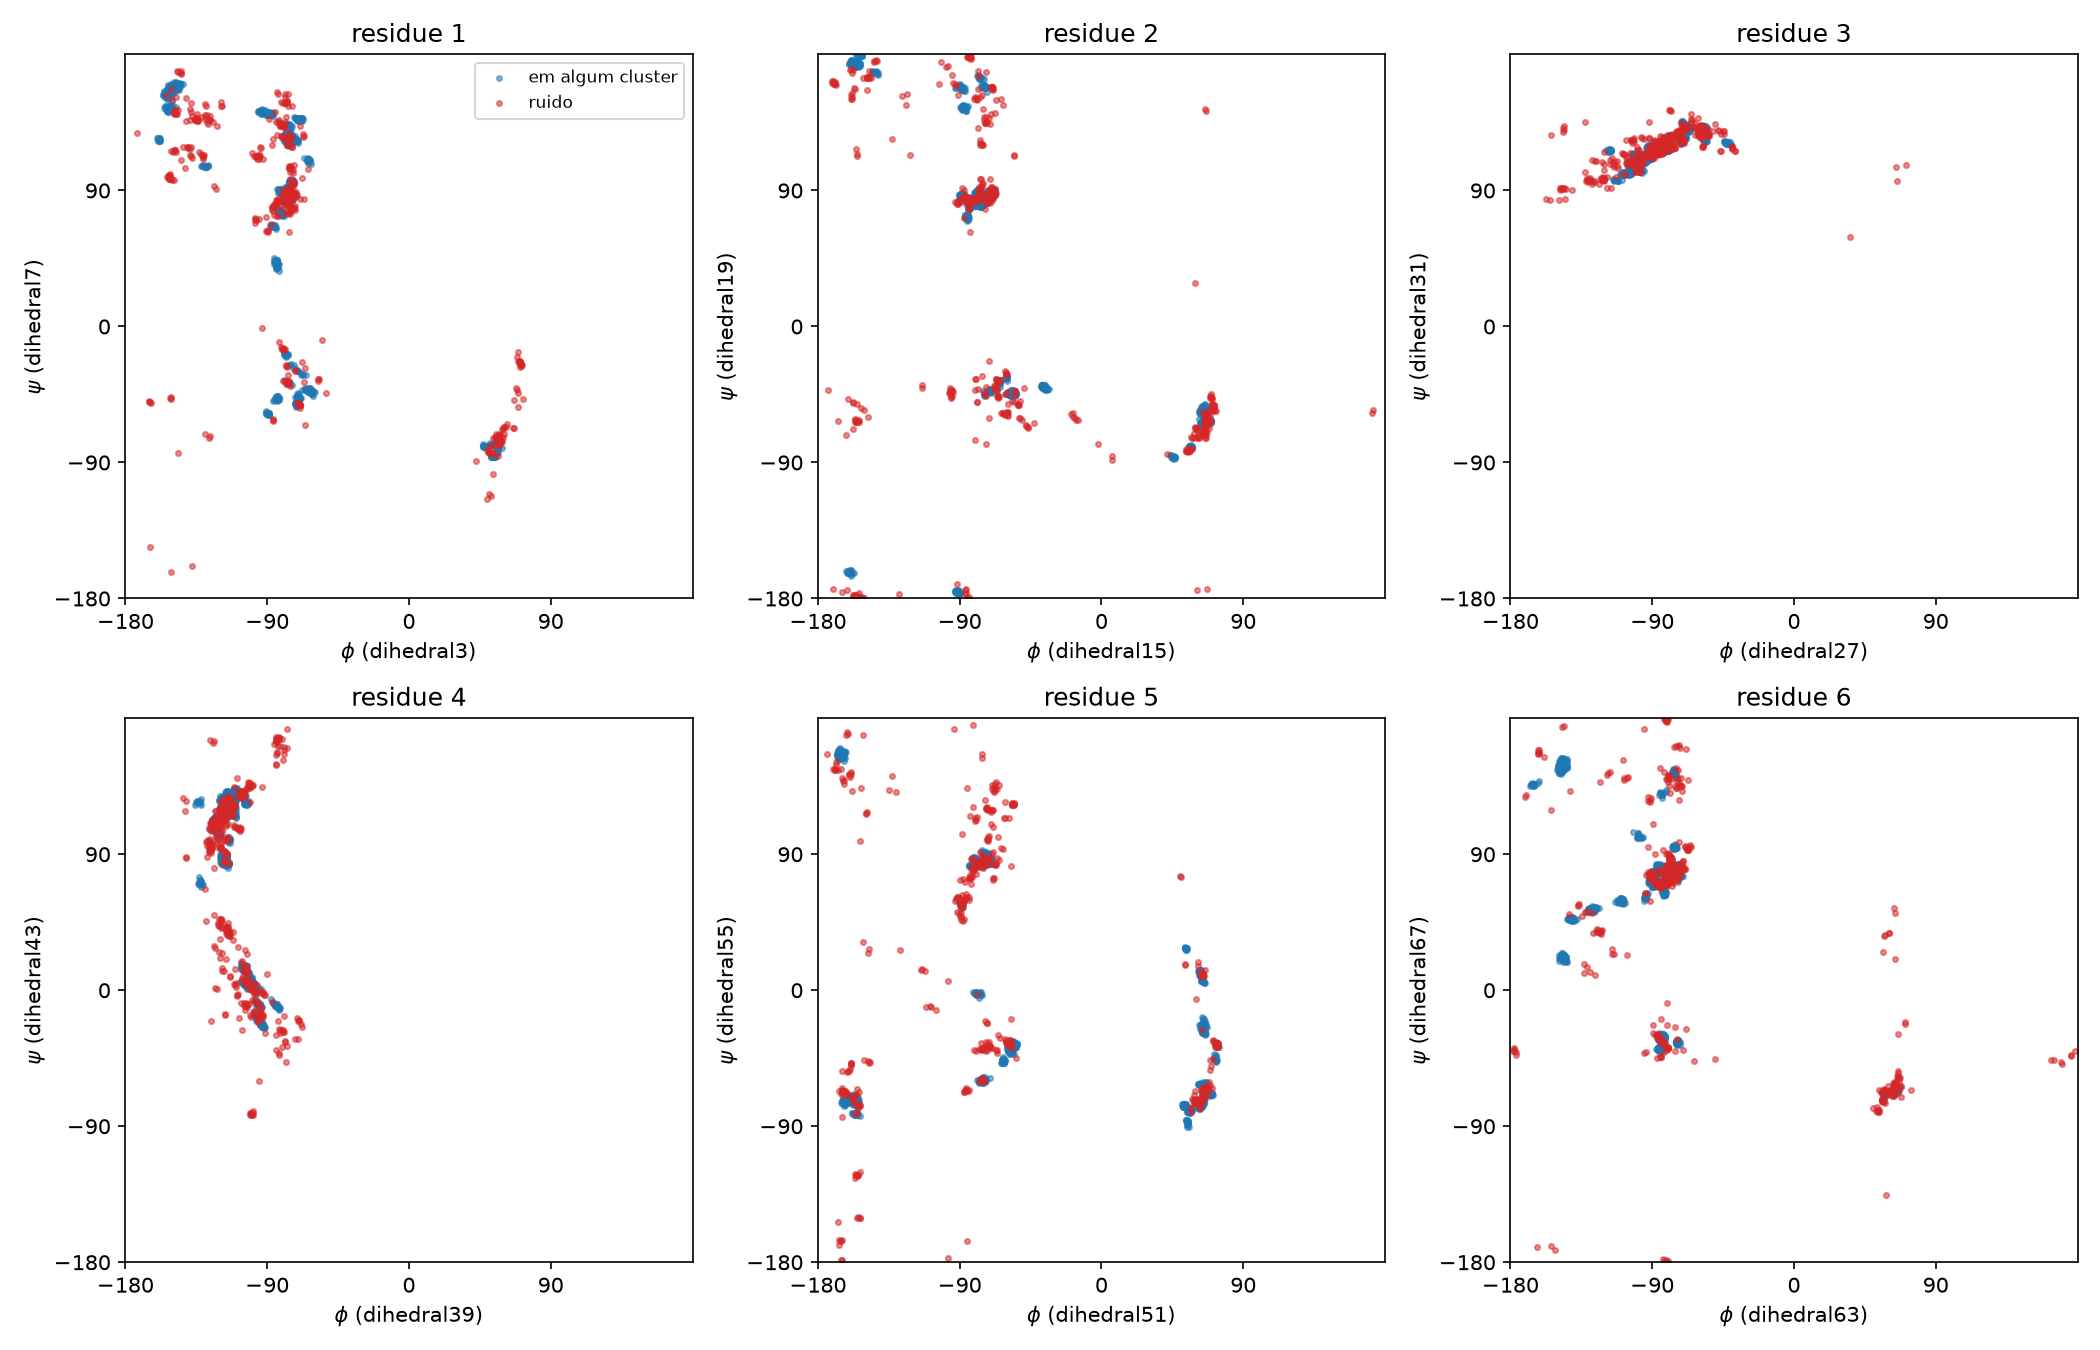

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(14, 9))
axs = axs.flatten()
is_noise = labels == -1
for i, ax in enumerate(axs):
    phi_name, psi_name = dihedral_names[2*i], dihedral_names[2*i+1]
    ax.scatter(df_features[phi_name][~is_noise], df_features[psi_name][~is_noise],
              s=6, alpha=0.5, c="C0", label="em algum cluster")
    ax.scatter(df_features[phi_name][is_noise], df_features[psi_name][is_noise],
              s=6, alpha=0.5, c="C3", label="ruido")
    ax.set(xlim=(-180, 180), ylim=(-180, 180),
          xticks=np.arange(-180, 180, 90), yticks=np.arange(-180, 180, 90))
    ax.set_xlabel(r"$\phi$" + f" ({phi_name})")
    ax.set_ylabel(r"$\psi$" + f" ({psi_name})")
    ax.set_title(f"residue {i + 1}")
axs[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## O que isso quer dizer

O ruido nao fica so' nas bordas entre bacias, como seria de se esperar -- ele aparece espalhado ate' dentro de bacias que, olhando so' phi/psi de um residuo, parecem bem densas e compactas. Isso e' esperado: a densidade e' calculada nas **12 dimensoes** de uma vez, entao um ponto pode estar bem no meio de uma bacia num residuo e ser um pouco atipico em outro -- o suficiente pra cair fora do raio `eps` de vizinhos suficientes e virar ruido. Esse efeito (metodos de densidade ficarem mais dificeis conforme o numero de dimensoes cresce) e' conhecido como *maldicao da dimensionalidade*, e explica tanto o numero grande de clusters pequenos quanto a fracao alta de ruido.

Isso nao invalida o DBSCAN -- ele so' esta respondendo uma pergunta diferente do K-means. Em vez de "quais sao os $K$ estados", ele pergunta "quais pontos tem vizinhanca densa o bastante pra formar um grupo confiavel", e a resposta honesta aqui e' que boa parte da trajetoria (24%) nao satisfaz esse criterio com folga.